# Pricing American Options via Longstaff–Schwartz in QMCPy

This notebook demonstrates the pricing of an **American Put Option** under Geometric Brownian Motion (GBM) using the **Longstaff–Schwartz (LSM)** algorithm and QMCPy's adaptive stopping criterion `CubQMCAmericanG`.

### Key Architectural Concepts
1. **Early Exercise Policy**: Longstaff–Schwartz estimates the continuation value at discrete exercise dates $0 < t_1 < \dots < t_d = T$ by regressing discounted future cash flows on a 4-term Laguerre basis using in-the-money (ITM) paths.
2. **Clean Separation of Training and Pricing**:
   - **Training Phase**: Dedicated training paths generate regression coefficients $\hat{\beta}_1, \dots, \hat{\beta}_{d-1}$ which define a frozen exercise policy $\pi$.
   - **Pricing Phase**: Independently generated pricing paths evaluate the frozen exercise policy without any re-regression.
3. **Prevention of Double Discounting**: The pointwise payoff returned by the American option evaluator is already discounted to time 0 ($e^{-r \tau_\pi}$). QMCPy's integration machinery handles the pricing sample without applying additional discounting.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/AmericanOption.ipynb)

In [9]:
# Import necessary packages
import qmcpy as qp
import numpy as np
import time
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 1. Single American Put Option Valuation

We setup an American Put option under GBM with the following parameters:
- Initial stock price $S_0 = 100$
- Strike price $K = 100$
- Risk-free interest rate $r = 0.05$
- Volatility $\sigma = 0.20$
- Maturity $T = 1.0$ year
- Monitoring dates $d = 10$


In [10]:
# Setup parameters
S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.20
T = 1.0
d = 10
n_train = 4096
abs_tol = 0.05

t0 = time.perf_counter()

# Create American Put integrand with Sobol sequence
sampler = qp.Sobol(dimension=d, seed=7)
american_put = qp.FinancialOption(
    sampler=sampler,
    option="AMERICAN",
    call_put="PUT",
    start_price=S0,
    strike_price=K,
    interest_rate=r,
    volatility=sigma,
    t_final=T
)

# Instantiate stopping criterion and perform integration
sc = qp.CubQMCAmericanG(american_put, abs_tol=abs_tol, n_train=n_train)
estimated_value, data = sc.integrate()

total_time = time.perf_counter() - t0

print("=" * 50)
print("  American Put Option Pricing (Longstaff-Schwartz)")
print("=" * 50)
print(f"Estimated Option Value : {estimated_value:.4f}")
print(f"Number of Training Samples: {data.n_train}")
print(f"Number of Pricing Samples : {data.n_total}")
print(f"Total Algorithm Time   : {total_time:.4f} seconds")
print("=" * 50)

  American Put Option Pricing (Longstaff-Schwartz)
Estimated Option Value : 5.9786
Number of Training Samples: 4096
Number of Pricing Samples : 1024
Total Algorithm Time   : 0.1072 seconds


## 2. Policy Convergence vs. Training Sample Size

To demonstrate the stability and convergence of the learned exercise policy, we evaluate the estimated American put value across training sample sizes $N_{train} \in [2^8, 2^9, \dots, 2^{13}]$.

Training Samples (N_train)   | Estimated Value | Runtime (s)
------------------------------------------------------------
256                          | 5.9025          | 0.0243    
512                          | 5.9935          | 0.0192    
1024                         | 5.9381          | 0.0127    
2048                         | 5.9486          | 0.0120    
4096                         | 5.9688          | 0.0122    
8192                         | 5.9989          | 0.0173    


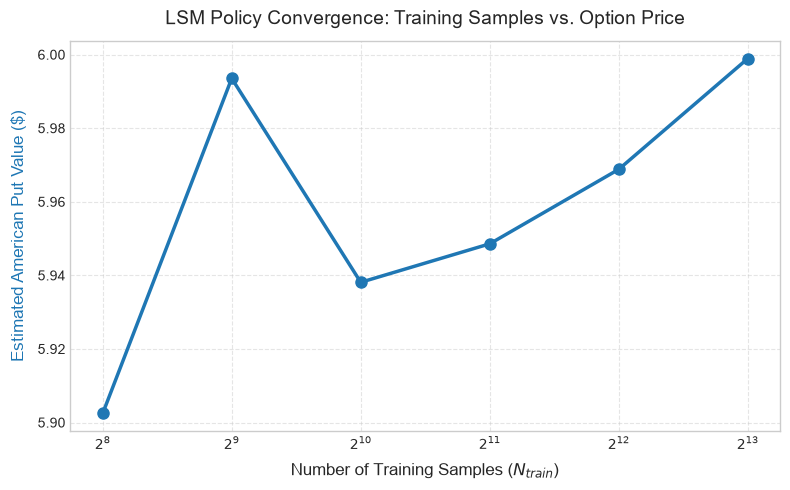

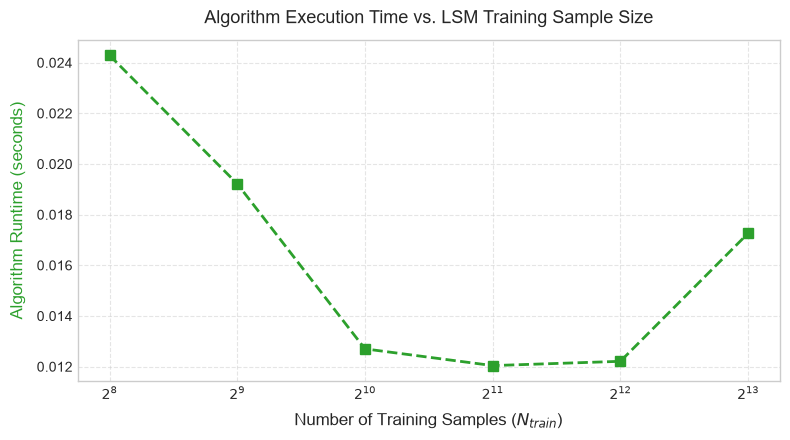

In [11]:
train_sizes = [2**k for k in range(8, 14)]
price_estimates = []
runtimes = []

print(f"{'Training Samples (N_train)':<28} | {'Estimated Value':<15} | {'Runtime (s)':<10}")
print("-" * 60)
for n_tr in train_sizes:
    t_start = time.perf_counter()
    opt = qp.FinancialOption(
        qp.Sobol(dimension=d, seed=42),
        option="AMERICAN",
        call_put="PUT",
        start_price=S0,
        strike_price=K,
        interest_rate=r,
        volatility=sigma,
        t_final=T
    )
    sc_eval = qp.CubQMCAmericanG(opt, abs_tol=0.02, n_train=n_tr)
    val, _ = sc_eval.integrate()
    elapsed = time.perf_counter() - t_start
    price_estimates.append(val)
    runtimes.append(elapsed)
    print(f"{n_tr:<28} | {val:<15.4f} | {elapsed:<10.4f}")

# Plot 1: Training Samples vs Estimated American Put Value
fig, ax1 = plt.subplots(figsize=(8, 5))
color = '#1f77b4'
ax1.set_xlabel('Number of Training Samples ($N_{train}$)', fontsize=12, labelpad=8)
ax1.set_ylabel('Estimated American Put Value ($)', color=color, fontsize=12, labelpad=8)
ax1.plot(train_sizes, price_estimates, 'o-', color=color, linewidth=2.5, markersize=8, label='Estimated Price')
ax1.set_xscale('log', base=2)
ax1.set_xticks(train_sizes)
ax1.set_xticklabels([f'$2^{{{int(np.log2(n))}}}$' for n in train_sizes])
ax1.grid(True, which="both", ls="--", alpha=0.5)
plt.title('LSM Policy Convergence: Training Samples vs. Option Price', fontsize=14, pad=12)
fig.tight_layout()
plt.show()

# Plot 2: Training Samples vs Runtime
fig, ax2 = plt.subplots(figsize=(8, 4.5))
color = '#2ca02c'
ax2.set_xlabel('Number of Training Samples ($N_{train}$)', fontsize=12, labelpad=8)
ax2.set_ylabel('Algorithm Runtime (seconds)', color=color, fontsize=12, labelpad=8)
ax2.plot(train_sizes, runtimes, 's--', color=color, linewidth=2, markersize=7, label='Runtime')
ax2.set_xscale('log', base=2)
ax2.set_xticks(train_sizes)
ax2.set_xticklabels([f'$2^{{{int(np.log2(n))}}}$' for n in train_sizes])
ax2.grid(True, which="both", ls="--", alpha=0.5)
plt.title('Algorithm Execution Time vs. LSM Training Sample Size', fontsize=13, pad=12)
fig.tight_layout()
plt.show()

## 3. Tolerance vs. Samples & Tolerance vs. Time

We examine how the requested error tolerance (`abs_tol`) affects:
1. **Required Pricing Samples ($N_{pricing}$)**
2. **Total Execution Time (seconds)**

We evaluate absolute tolerances: `abs_tol` $\in [0.10, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]$.

Tolerance (abs_tol)  | Estimated Value | Pricing Samples    | Total Time (s)
------------------------------------------------------------------------
0.100                | 5.9786          | 1024               | 0.0098    
0.050                | 5.9786          | 1024               | 0.0079    
0.020                | 6.0085          | 2048               | 0.0115    
0.010                | 6.0351          | 8192               | 0.0173    
0.005                | 6.0398          | 32768              | 0.0456    
0.002                | 6.0217          | 131072             | 0.1722    
0.001                | 6.0238          | 524288             | 0.8090    


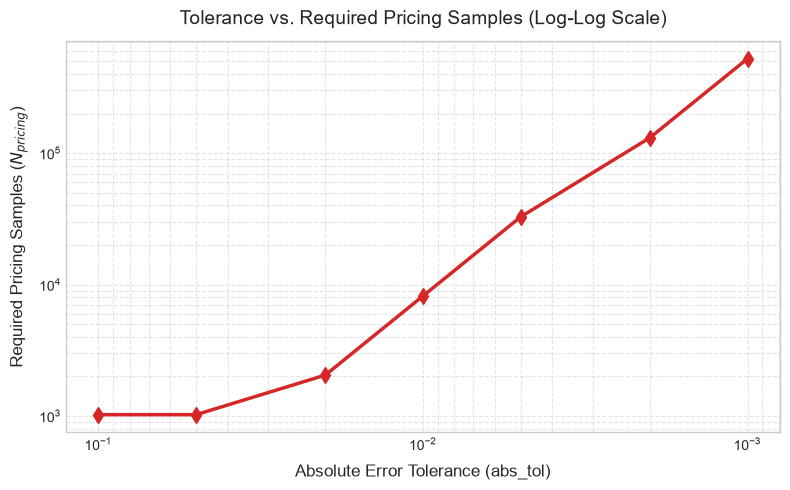

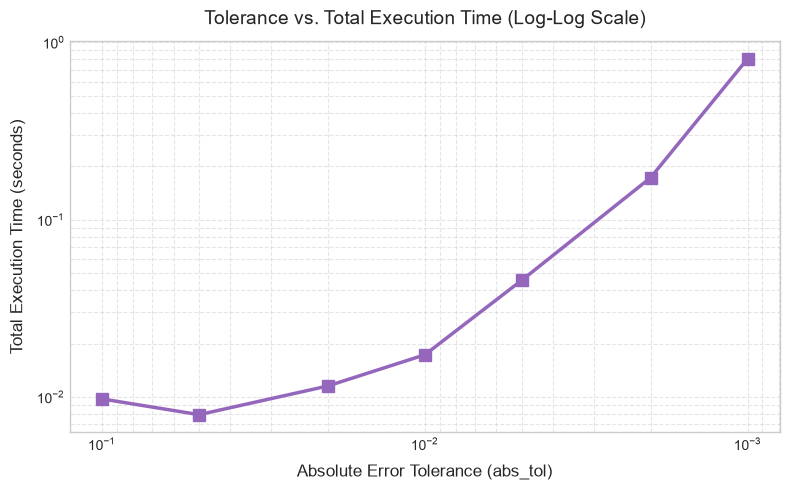

In [12]:
tols = [0.10, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]
pricing_samples = []
tol_runtimes = []
pricing_solutions = []

print(f"{'Tolerance (abs_tol)':<20} | {'Estimated Value':<15} | {'Pricing Samples':<18} | {'Total Time (s)':<10}")
print("-" * 72)

for tol in tols:
    t_start = time.perf_counter()
    opt = qp.FinancialOption(
        qp.Sobol(dimension=d, seed=7),
        option="AMERICAN",
        call_put="PUT",
        start_price=S0,
        strike_price=K,
        interest_rate=r,
        volatility=sigma,
        t_final=T
    )
    sc = qp.CubQMCAmericanG(opt, abs_tol=tol, n_train=4096)
    sol, data = sc.integrate()
    elapsed = time.perf_counter() - t_start
    
    pricing_samples.append(data.n_total)
    tol_runtimes.append(elapsed)
    pricing_solutions.append(sol)
    
    print(f"{tol:<20.3f} | {sol:<15.4f} | {data.n_total:<18} | {elapsed:<10.4f}")

# Plot 3A: Tolerance vs Pricing Samples (log-log)
fig, ax_samp = plt.subplots(figsize=(8, 5))
ax_samp.loglog(tols, pricing_samples, 'd-', color='#d62728', linewidth=2.5, markersize=8, label='Pricing Samples')
ax_samp.set_xlabel('Absolute Error Tolerance (abs_tol)', fontsize=12, labelpad=8)
ax_samp.set_ylabel('Required Pricing Samples ($N_{pricing}$)', fontsize=12, labelpad=8)
ax_samp.invert_xaxis()  # Tightening tolerance moves left-to-right
ax_samp.grid(True, which="both", ls="--", alpha=0.5)
plt.title('Tolerance vs. Required Pricing Samples (Log-Log Scale)', fontsize=14, pad=12)
fig.tight_layout()
plt.show()

# Plot 3B: Tolerance vs Total Execution Time (log-log)
fig, ax_time = plt.subplots(figsize=(8, 5))
ax_time.loglog(tols, tol_runtimes, 's-', color='#9467bd', linewidth=2.5, markersize=8, label='Execution Time')
ax_time.set_xlabel('Absolute Error Tolerance (abs_tol)', fontsize=12, labelpad=8)
ax_time.set_ylabel('Total Execution Time (seconds)', fontsize=12, labelpad=8)
ax_time.invert_xaxis()
ax_time.grid(True, which="both", ls="--", alpha=0.5)
plt.title('Tolerance vs. Total Execution Time (Log-Log Scale)', fontsize=14, pad=12)
fig.tight_layout()
plt.show()

## 4. Multi-Distribution Compatibility

The American option stopping criterion `CubQMCAmericanG` seamlessly supports multiple discrete distributions available in QMCPy:
- **Sobol** (`DigitalNetB2`)
- **Lattice**
- **Halton**
- **IID** (`IIDStdUniform`)

In [13]:
distributions = {
    "Sobol": qp.Sobol(dimension=d, seed=123),
    "Lattice": qp.Lattice(dimension=d, seed=123),
    "Halton": qp.Halton(dimension=d, seed=123),
    "IID": qp.IIDStdUniform(dimension=d, seed=123)
}

print(f"{'Distribution':<15} | {'Estimated Value':<15} | {'Pricing Samples':<15} | {'Time (s)':<10}")
print("-" * 65)

for dist_name, dist_obj in distributions.items():
    t_start = time.perf_counter()
    opt = qp.FinancialOption(
        dist_obj,
        option="AMERICAN",
        call_put="PUT",
        start_price=S0,
        strike_price=K,
        interest_rate=r,
        volatility=sigma,
        t_final=T
    )
    sc = qp.CubQMCAmericanG(opt, abs_tol=0.05, n_train=4096)
    val, data = sc.integrate()
    elapsed = time.perf_counter() - t_start
    print(f"{dist_name:<15} | {val:<15.4f} | {data.n_total:<15} | {elapsed:<10.4f}")

Distribution    | Estimated Value | Pricing Samples | Time (s)  
-----------------------------------------------------------------
Sobol           | 6.1224          | 1024            | 0.0102    
Lattice         | 5.9316          | 1024            | 0.0098    
Halton          | 6.0229          | 32768           | 0.4783    
IID             | 6.0589          | 206226          | 0.2291    
